In [2]:
!pip install yfinance

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------------------- - 1.6/1.6 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 7.2 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15702 sha256=c7f9dc85acb6c0082ee828a162edb60492b57ac8b4e5b7bc4a3d5ccc46817dc6
  Stored in directory: c:\users\shrey\appdata\local\pip\cache\wheels\42\d6\84\bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
Successfully built multitasking

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ----------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------------------- ---------------- 1.0/1.8 MB 12.7 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 9.8 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0
    Uninstalling pip-26.0:
      Successfully uninstalled pip-26.0
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [6]:
data = yf.download("AAPL", start="2022-01-01", end="2026-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843262,179.013730,175.275708,178.710386,99310400
2022-01-05,171.165848,176.303172,170.891858,175.755193,94537600
2022-01-06,168.308517,171.537695,167.956243,168.993491,96904000
2022-01-07,168.474838,170.402559,167.359306,169.179387,86709100


In [8]:
data['log_return'] = np.log(data['Close'] / data['Close'].shift(1))
data['RV'] = data['log_return'] ** 2

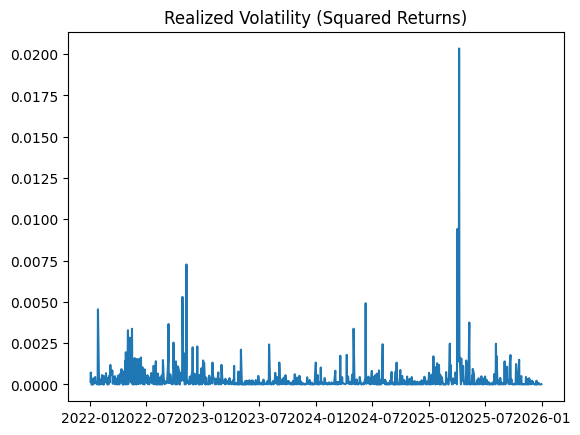

In [9]:
plt.figure()
plt.plot(data['RV'])
plt.title("Realized Volatility (Squared Returns)")
plt.show()

In [10]:
data['RV_t+1'] = data['RV'].shift(-1)
data['baseline_pred'] = data['RV']